In [1]:
%load_ext autoreload
%autoreload 2
import pylupnt as pnt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Backend for matplotlib (inline, TkAgg, Qt5Agg, WXAgg, GTKAgg, Agg, ps, pdf, svg, cairo, Macosx, WebAgg, nbAgg, template)
%matplotlib widget

## Regions of Interest

In [2]:
# Regions of interest (permanently shadowed regions)
regions_psr_df = pd.read_excel('data/permanently-shadowed-regions.xlsx')
lats_psr = regions_psr_df["Cent. Lat."].values
lons_psr = regions_psr_df["Cent. Long."].values - 180
areas_psr = regions_psr_df["Area (km2)"].values
coverage_psr = regions_psr_df["Coverage (%)"].values
alts_psr = np.zeros_like(lats_psr)
regions_psr_df.head()

,PSR ID,Cent. Lat.,Cent. Long.,Area (km2),Perimeter (km),Features of Interest,Lunar Features,Coverage (%),Data Quality
0,SP_896450_1282030,-89.645,128.203,233.698,70.32,"2012-258 (M1102304370R): 129.549, -89.632 (S80...",Shackleton Crater,65,1.0
1,SP_895060_2806850,-89.506,280.685,53.262,45.48,NaN,de Gerlache Crater Shackleton Crater,0,NaN
2,SP_890390_3377770,-89.039,337.777,60.358,54.24,NaN,Haworth Crater Shackleton Crater,0,NaN
3,SP_889970_3170870,-88.997,317.087,44.284,49.56,NaN,de Gerlache Crater Haworth Crater,0,NaN
4,SP_889970_0191990,-88.997,19.199,55.408,36.84,NaN,Haworth Crater Shackleton Crater,10,1.0


In [3]:
# Regions of interest (impact craters)
regions_ic_df = pd.read_excel(
    "data/Lunar_Impact_Crater_Database_v08Sep2015.xls", sheet_name="Database"
)
regions_ic_df = regions_ic_df[regions_ic_df["3. Latitude [°]"] <= 90]
lats_ic = regions_ic_df["3. Latitude [°]"].values
lons_ic = regions_ic_df["4. Longitude [°]"].values
areas_ic = np.pi * np.square(regions_ic_df["6. Radius [km]"].values)
alts_ic = np.zeros_like(lats_ic)
regions_ic_df.head()

,1. Crater name,2. Diameter [km],3. Latitude [°],4. Longitude [°],5. East longitude [°],6. Radius [km],7. Radius [m],8. Apparent diameter [km],9. Transient cavity diameter [km],10. Transient cavity diameter [km],...,73. Average CF [μm],74. Average OMAT,75. Average FeO [wt.-%],76. OMAT range,77. Plg abundance class,78. Province,79. Peak degradation,80. PAN location,81. Rays,1. Crater name .1
0,Abbe,63.98,-57.58,174.77,174.77,31.990,31990.0,55.0228,51.469659,37.371461,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abbe
1,Abbe H,25.13,-58.44,177.58,177.58,12.565,12565.0,21.6118,23.258264,15.604124,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abbe H
2,Abbe K,26.10,-59.82,176.86,176.86,13.050,13050.0,22.4460,24.019177,16.166327,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abbe K
3,Abbe M,28.61,-61.75,175.24,175.24,14.305,14305.0,24.6046,25.968919,17.614889,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abbe M
4,Abbot,10.40,5.56,54.74,54.74,5.200,5200.0,8.6320,8.736000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abbot


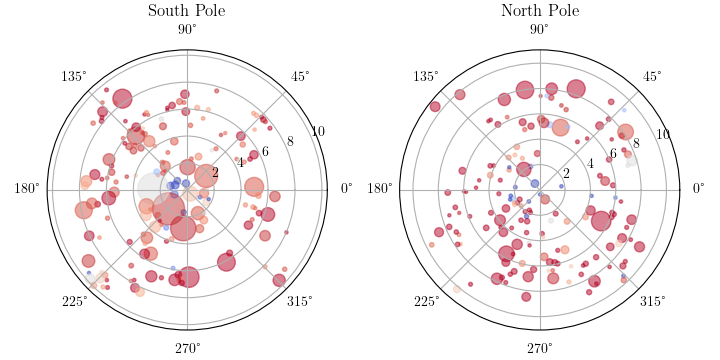

In [89]:
plot_scale = 0.5
fig_scale = 0.02

fig = plt.figure(figsize=(360 * fig_scale, 180 * fig_scale))
# Polar plot (South pole)
ax = fig.add_subplot(121, polar=True)
idxs = lats_psr < 0
ax.scatter(
    np.radians(lons_psr[idxs]),
    90 + lats_psr[idxs],
    c=coverage_psr[idxs],
    cmap="coolwarm",
    s=areas_psr[idxs] * plot_scale,
    alpha=0.5,
)
plt.title("South Pole")

# Polar plot (North pole)
ax = fig.add_subplot(122, polar=True)
idxs = lats_psr > 0
ax.scatter(
    np.radians(lons_psr[idxs]),
    90 - lats_psr[idxs],
    c=coverage_psr[idxs],
    cmap="coolwarm",
    s=areas_psr[idxs] * plot_scale,
    alpha=0.5,
)
plt.title("North Pole")
plt.savefig("figures/psr.pdf")
plt.tight_layout()
plt.show()

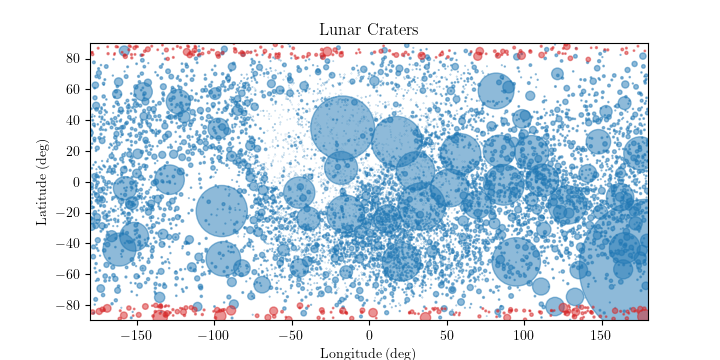

In [90]:
plot_scale = 0.002
fig_scale = 0.02
plt.figure(figsize=(360 * fig_scale, 180 * fig_scale))
plt.scatter(lons_ic, lats_ic, s=areas_ic * plot_scale, alpha=0.5, c="tab:blue")
plt.scatter(
    lons_psr,
    lats_psr,
    c="tab:red",
    s=areas_psr * plot_scale * 50,
    alpha=0.5,
)
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title("Lunar Craters")
plt.xlim(-180, 180)
plt.ylim(-90, 90)
p1 = plt.Circle((0, 0), 90, color="tab:blue", alpha=0.5)
p2 = plt.Circle((0, 0), 90, color="tab:red", alpha=0.5)
plt.legend(
    [p1, p2],
    ["Impact Craters", "Permanently Shadowed Regions"],
    loc="center left",
    ncol=2,
    bbox_to_anchor=(0.1, -0.25),
)
plt.savefig("figures/craters.pdf")
plt.show()

In [6]:
lats = np.concatenate([lats_ic, lats_psr])
lons = np.concatenate([lons_ic, lons_psr])
alts = np.concatenate([alts_ic, alts_psr])

# Satellite

In [7]:
# Epoch
epoch_0 = pnt.SpiceInterface.string_to_tai("2025/10/02 00:00:00.000 UTC")

# Orbital elements
sma = 5740               # [km]  a, Semi-major axis
ecc = 0.58               # [-]   e, Eccentricity
inc = np.deg2rad(54.856) # [rad] i, Inclination
raan = np.deg2rad(0)     # [rad] W, Right ascension of the ascending node
aop = np.deg2rad(86.322) # [rad] w, Argument of periapsis
ma = np.deg2rad(180)     # [rad] M, Mean anomaly
coe_sat_OP = np.array([sma, ecc, inc, raan, aop, ma])
rv_sat_OP = pnt.classical_to_cartesian(coe_sat_OP, pnt.MU_MOON)
rv_sat_mi = pnt.CoordConverter.convert(epoch_0, rv_sat_OP, pnt.OP, pnt.MI)

# Time
T = 2 * np.pi * np.sqrt(np.power(sma, 3) / pnt.MU_MOON)
dT = 5 * pnt.SECS_PER_MINUTE
dt = 5 * pnt.SECS_PER_MINUTE
tf = 1.5 * T
N_steps = int(tf / dT)
tspan = np.linspace(0, tf, N_steps)

# Dynamics
dynamics = pnt.NBodyDynamics()
dynamics.set_primary_body(pnt.Body.Moon())
dynamics.add_body(pnt.Body.Earth())
dynamics.set_time_step(dt)

Loaded All SPICE Kernels
Loaded Chebyshev coefficients for 14 planets.


In [91]:
# Propagation
rv = dynamics.propagate(rv_sat_mi, epoch_0, epoch_0 + tspan)
rv_earth = pnt.SpiceInterface.get_body_pos_vel(epoch_0, pnt.MOON, pnt.EARTH)

In [92]:
# Plot orbit
fig = pnt.plots.Plot3D(figsize=(5, 5))
fig.plot_surface(pnt.EARTH, offset=rv_earth, scale=3, adjust_axis=False)
fig.plot_surface(pnt.MOON, scale=3, adjust_axis=False)
fig.label_axis()
fig.plot(rv[:,0:3], label="Satellite", color="tab:blue")
plt.close(fig.fig)

In [93]:
# Locations
N_loc = 10
np.random.seed(0)
idxs_south_pole = np.where(lats < -60)[0]
idxs = np.random.choice(idxs_south_pole, N_loc)
loc_lats = np.deg2rad(lats[idxs])
loc_lons = np.deg2rad(lons[idxs])
loc_alts = alts[idxs]

r_obs_mi = np.zeros((N_loc, 3))
r_obs_pa = np.zeros((N_loc, 3))
for i in range(N_loc):
    r_obs_pa[i] = pnt.geographical_to_cartesian([loc_lats[i], loc_lons[i], loc_alts[i]], pnt.R_MOON)
    r_obs_mi[i] = pnt.CoordConverter.convert(epoch_0, r_obs_pa[i], pnt.PA, pnt.MI)

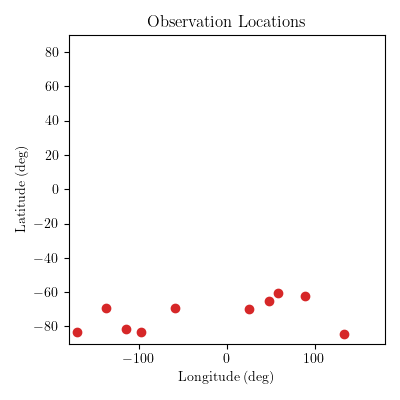

In [94]:
plt.figure(figsize=(4, 4))
plt.plot(np.rad2deg(loc_lons), np.rad2deg(loc_lats), "o", color="tab:red")
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title("Observation Locations")
plt.xlim(-180, 180)
plt.ylim(-90, 90)
plt.tight_layout()
plt.show()

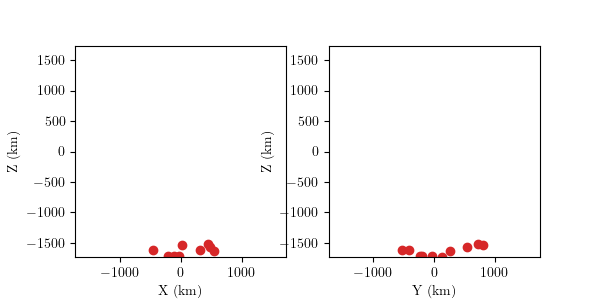

In [95]:
plt.figure(figsize=(6, 3))
plt.subplot(121)
plt.plot(r_obs_pa[:, 0], r_obs_pa[:, 2], "o", color="tab:red")
plt.xlabel("X (km)")
plt.ylabel("Z (km)")
plt.xlim(-pnt.R_MOON, pnt.R_MOON)
plt.ylim(-pnt.R_MOON, pnt.R_MOON)
plt.gca().set_aspect("equal", adjustable="box")

plt.subplot(122)
plt.plot(r_obs_pa[:, 1], r_obs_pa[:, 2], "o", color="tab:red")
plt.xlabel("Y (km)")
plt.ylabel("Z (km)")
plt.xlim(-pnt.R_MOON, pnt.R_MOON)
plt.ylim(-pnt.R_MOON, pnt.R_MOON)
plt.gca().set_aspect("equal", adjustable="box")

plt.show()

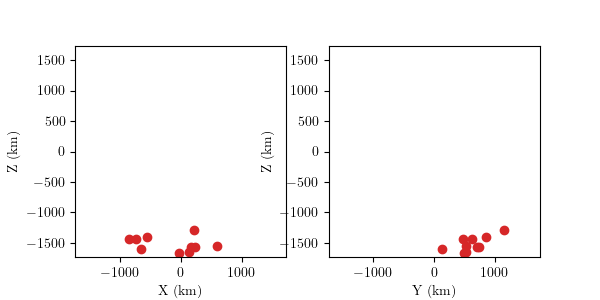

In [96]:
plt.figure(figsize=(6, 3))
plt.subplot(121)
plt.plot(r_obs_mi[:, 0], r_obs_mi[:, 2], "o", color="tab:red")
plt.xlabel("X (km)")
plt.ylabel("Z (km)")
plt.xlim(-pnt.R_MOON, pnt.R_MOON)
plt.ylim(-pnt.R_MOON, pnt.R_MOON)
plt.gca().set_aspect("equal", adjustable="box")

plt.subplot(122)
plt.plot(r_obs_mi[:, 1], r_obs_mi[:, 2], "o", color="tab:red")
plt.xlabel("Y (km)")
plt.ylabel("Z (km)")
plt.xlim(-pnt.R_MOON, pnt.R_MOON)
plt.ylim(-pnt.R_MOON, pnt.R_MOON)
plt.gca().set_aspect("equal", adjustable="box")

plt.show()

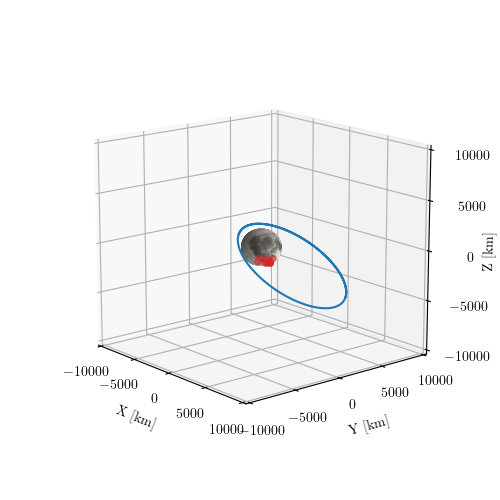

In [98]:
# Plot orbit
fig = pnt.plots.Plot3D(figsize=(5, 5), elev=15, azim=-40)
fig.plot_surface(pnt.MOON, scale=3)
fig.label_axis()
fig.plot(rv[:,0:3], label="Satellite", color="tab:blue", mask=False)
fig.scatter(r_obs_mi, label="Observation Locations", color="tab:red", mask=False)
# Change z-axis label margin
fig.ax.zaxis.labelpad = 5
plt.savefig("figures/obs_locations.pdf")
plt.show()

In [ ]:
# ELevation angles


# MILP

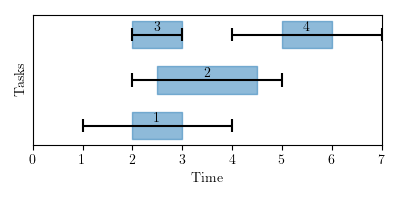

In [68]:
from SatelliteTaskingMdp import Task, Opportunity, Satellite, TaskType
import utils

Opportunity.id_count = 0
opportunities = [
    Opportunity(time_start=0, time_end=1, duration=1, power=0, data=0, type=TaskType.START),
    Opportunity(time_start=1, time_end=4, duration=1),
    Opportunity(time_start=2, time_end=5, duration=2),
    Opportunity(time_start=2, time_end=3, duration=1),
    Opportunity(time_start=4, time_end=7, duration=1),
    Opportunity(time_start=1, time_end=7, duration=6, power=1, data=0, reward=0, type=TaskType.SUN_POINTING),
    Opportunity(time_start=1, time_end=7, duration=6, power=0, data=-1, reward=0, type=TaskType.DOWNLINK),
]

slew_times = np.ones((len(opportunities), len(opportunities))) * np.inf
slew_times[0, :] = 1
slew_times[1, :] = 2
slew_times[2, 1:] = 3
slew_times[3, 1:] = 4

plt.figure(figsize=(4, 2))
utils.plot_opportunity_windows(opportunities)
plt.tight_layout()
plt.savefig("figures/tasks.pdf")
plt.show()

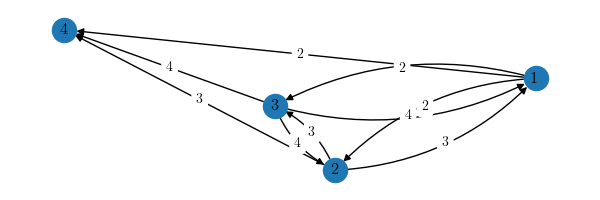

In [64]:
import networkx as nx
np.random.seed(0)

G = nx.DiGraph()
for i, op_1 in enumerate(opportunities):
    for j, op_2 in enumerate(opportunities):
        if i == j:
            continue
        if slew_times[i, j] < np.inf and op_1.type == TaskType.SCIENCE and op_2.type == TaskType.SCIENCE:
            G.add_edge(op_1.id, op_2.id, weight=slew_times[i, j])


fig, ax = plt.subplots(figsize=(6, 2))
pos = nx.spring_layout(G)
nx.draw_networkx_nodes(G, pos)
nx.draw_networkx_labels(G, pos)

arc_rad = 0.2
curved_edges = [edge for edge in G.edges() if reversed(edge) in G.edges()]
straight_edges = list(set(G.edges()) - set(curved_edges))
nx.draw_networkx_edges(G, pos, edgelist=straight_edges)
nx.draw_networkx_edges(G, pos, edgelist=curved_edges, connectionstyle=f'arc3, rad = {arc_rad}')

edge_weights = nx.get_edge_attributes(G,'weight')
curved_edge_labels = {edge: int(edge_weights[edge]) for edge in curved_edges}
straight_edge_labels = {edge: int(edge_weights[edge]) for edge in straight_edges}
utils.my_draw_networkx_edge_labels(G, pos, ax=ax, edge_labels=curved_edge_labels,rotate=False,rad = arc_rad)
nx.draw_networkx_edge_labels(G, pos, ax=ax, edge_labels=straight_edge_labels,rotate=False)
plt.axis('off')
plt.tight_layout()
plt.savefig("figures/slew_times.pdf")
plt.show()

Problem status: optimal
Objective value: 3.97
Selected opportunities:
[1. 1. 0. 1. 1. 1. 1.]
Times:
[[1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]]


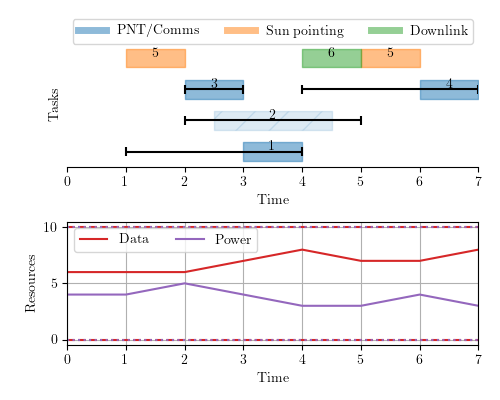

In [70]:
import math
import cvxpy as cp

data_min = 0
data_max = 10
data_initial = 6

power_min = 0
power_max = 10
power_initial = 4

N_t = 8
N_o = len(opportunities)
lambda_data = 0.01
lambda_power = 0.01
# Variables
opp_selected = cp.Variable(N_o, boolean=True)
opp_times = cp.Variable((N_o, N_t), boolean=True)
# Resources
data_array = np.array([[op.data] for op in opportunities])
power_array = np.array([[op.power] for op in opportunities])
data_var = cp.sum(cp.multiply(opp_times, data_array), axis=0)
power_var = cp.sum(cp.multiply(opp_times, power_array), axis=0)
lower_diag = np.tril(np.ones((N_t, N_t)), k=0)
# Rewards
rewards = np.array([op.reward for op in opportunities])
# Objective
objective = cp.Maximize(
    rewards @ opp_selected
    - lambda_data * cp.max(lower_diag @ data_var)
    + lambda_power * cp.min(lower_diag @ power_var)
)
# Constraints
constraints = [opp_selected[0] == 1]
for i, opp in enumerate(opportunities):
    # Start and end times
    valid_times = np.zeros(N_t)
    ts, te = math.floor(opp.time_start), math.ceil(opp.time_end)
    valid_times[ts:te] = 1
    constraints.append(opp_times[i, :] <= valid_times * opp_selected[i])
    # Duration constraint
    if opp.type == TaskType.SCIENCE:
        constraints.append(cp.sum(opp_times[i, :]) == opp.duration * opp_selected[i])
    else:
        constraints.append(cp.sum(opp_times[i, :]) >= opp_selected[i])
        constraints.append(cp.sum(opp_times[i, :]) <= N_t * opp_selected[i])
# One task per time
constraints.append(cp.sum(opp_times, axis=0) <= 1)
constraints.append(lower_diag @ data_var + data_initial >= data_min)
constraints.append(lower_diag @ data_var + data_initial <= data_max)
constraints.append(lower_diag @ power_var + power_initial >= power_min)
constraints.append(lower_diag @ power_var + power_initial <= power_max)

# Problem
problem = cp.Problem(objective, constraints)
# Solve
problem.solve()
print("Problem status:", problem.status)
print("Objective value:", problem.value)
print("Selected opportunities:")
print(opp_selected.value)
print("Times:")
print(opp_times.value)

start_end_times = {}
for i, opp in enumerate(opportunities):
    if opp_selected.value[i]:
        start_times = np.where(np.diff(np.append([0], opp_times.value[i, :])) == 1)[0]
        end_times = np.where(np.diff(np.append(opp_times.value[i, :], [0])) == -1)[0] + 1
        start_end_times[opp.id] = (start_times, end_times)

# Schedule
plt.figure(figsize=(5, 4))
plt.subplot(211)
utils.plot_opportunity_windows(opportunities, start_end_times, plot_all=True)

# Resources
plt.subplot(212)
t_plot = np.arange(N_t + 1)
data_plot = np.append([data_initial], lower_diag @ data_var.value + data_initial)
power_plot = np.append([power_initial], lower_diag @ power_var.value + power_initial)
plt.plot(t_plot, data_plot, label="Data", color=utils.TABLEAU_COLORS[3])
plt.plot(t_plot, power_plot, label="Power", color=utils.TABLEAU_COLORS[4])
plt.hlines([data_min, data_max], 0, N_t, color=utils.TABLEAU_COLORS[3], linestyle="--")#, label="Data limits")
plt.hlines([power_min, power_max], 0, N_t, color=utils.TABLEAU_COLORS[4], linestyle=":")#, label="Power limits")
plt.xlabel("Time")
plt.ylabel("Resources")
plt.xlim(0,7)
plt.legend(ncol=2)
plt.grid()

plt.tight_layout()
plt.savefig("figures/schedule.pdf")
plt.show()

# Forward Search

In [18]:
from SatelliteTaskingMdp import SatelliteTaskingMdp, SmdpForwardSearch, SatelliteState

planning_horizon = 7
solve_depth = 15
discount_factor = 0.9
model = SatelliteTaskingMdp()
solver = SmdpForwardSearch(model)
state = SatelliteState(0, set(opportunities), data_initial, power_initial)
policy = solver.solve(state, solve_depth, discount_factor)

UnboundLocalError: cannot access local variable 'opportunities' where it is not associated with a value

In [ ]:
for s, a in policy:
    print(s.time, a.opportunity.id)

0 0
1 3
2 1


In [ ]:

model_py = SatelliteTaskingProblem()
model_gen = MDP.GenerativeModelPython(model_py)

n_iterations = 100
exploration_constant = 5.0
model_mcts = MDP.MCTSGenerativeModelPython(model_gen, n_iterations, exploration_constant)

NameError: name 'SatelliteTaskingProblem' is not defined

## Constraint Checks

In [ ]:
opp_selected.value = np.array([1, 1, 1, 1, 1, 0, 0])
opp_times.value = np.array([
    [1, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0 ,0, 0, 0, 0, 0],
    [0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
])

# Constraints
constraints = [opp_selected.value[0] == 1]
for i, opp in enumerate(opportunities):
    # Start and end times
    valid_times = np.zeros(N_t)
    ts, te = math.floor(opp.time_start), math.ceil(opp.time_end)
    valid_times[ts:te] = 1
    constraints.append(opp_times.value[i, :] <= valid_times * opp_selected.value[i])
    # Duration constraint
    if opp.type == TaskType.SCIENCE:
        constraints.append(np.sum(opp_times.value[i, :]) == opp.duration * opp_selected.value[i])
    else:
        constraints.append(np.sum(opp_times.value[i, :]) >= opp_selected.value[i])
        constraints.append(np.sum(opp_times.value[i, :]) <= N_t * opp_selected.value[i])
# One task per time
data_var = np.sum(np.multiply(opp_times.value, data_array), axis=0)
power_var = np.sum(np.multiply(opp_times.value, power_array), axis=0)
constraints.append(np.sum(opp_times.value, axis=0) <= 1)
constraints.append(lower_diag @ power_var + power_initial >= power_min)
constraints.append(lower_diag @ power_var + power_initial <= power_max)
constraints

[True,
 array([ True,  True,  True,  True,  True,  True,  True,  True]),
 True,
 True,
 array([ True,  True,  True,  True,  True,  True,  True,  True]),
 True,
 array([ True,  True,  True,  True,  True,  True,  True,  True]),
 True,
 array([ True,  True,  True,  True, False,  True,  True,  True]),
 True,
 array([ True,  True,  True,  True,  True,  True,  True,  True]),
 True,
 array([ True,  True,  True,  True,  True,  True,  True,  True]),
 True,
 True,
 array([ True,  True,  True,  True,  True,  True,  True,  True]),
 True,
 True,
 array([ True,  True,  True,  True,  True,  True,  True,  True]),
 array([ True,  True,  True,  True,  True,  True,  True,  True]),
 array([ True,  True,  True,  True,  True,  True,  True,  True])]

In [ ]:
i, opp = 0, opportunities[0]
# Start and end times
valid_times = np.zeros(N_t)
ts, te = math.floor(opp.time_start), math.ceil(opp.time_end)
valid_times[ts:te] = 1
print(opp_times.value[:, i] <= valid_times * opp_selected.value[i])

ValueError: operands could not be broadcast together with shapes (7,) (8,) 